In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la
from matplotlib.collections import LineCollection

from tqdm import tqdm

from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala.lattice import cut_boundaries
from koala.graph_utils import make_dual, lloyd_relaxation, remove_trailing_edges
from koala import plotting as kplt
import matplotlib
from matplotlib.colors import TwoSlopeNorm

matplotlib.rcParams.update({'font.size': 11, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern']})

In [2]:
def qwz_hamiltonian(lattice, u_vals, h_field = 0):
    if isinstance(u_vals, (int, float, complex)):
        u_vals = np.array([u_vals] * lattice.n_vertices)

    a_site_part = np.diag(u_vals+0j)
    b_site_part = -np.diag(u_vals+0j)

    ab_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)
    ba_link_part = np.zeros((lattice.n_vertices, lattice.n_vertices), dtype = complex)

    p1 = lattice.vertices.positions[lattice.edges.indices[:, 0]]
    p2 = lattice.vertices.positions[lattice.edges.indices[:, 1]]   
    average_y = 0.5*(p1[:,1] + p2[:,1])
    change_x = p2[:,0] - p1[:,0]
    phases = -h_field * average_y * change_x * lattice.n_plaquettes

    for edge_index in range(lattice.n_edges):

        field_phase = 1j*phases[edge_index]*2*np.pi
        
        edge = lattice.edges.indices[edge_index]

        vec = lattice.edges.vectors[edge_index]
        angle = np.angle(vec[0] + 1j * vec[1])

        ab_link_part[edge[0], edge[1]] = 0.5j*np.exp(-1j*angle + field_phase)
        ba_link_part[edge[0], edge[1]] = 0.5j*np.exp(1j*angle + field_phase)
        a_site_part[edge[0], edge[1]] = 0.5*np.exp(field_phase)
        b_site_part[edge[0], edge[1]] = -0.5*np.exp(field_phase)

        # add conjugates
        ba_link_part[edge[1], edge[0]] = -0.5j*np.exp(1j*angle - field_phase)
        ab_link_part[edge[1], edge[0]] = -0.5j*np.exp(-1j*angle - field_phase)
        a_site_part[edge[1], edge[0]] = 0.5*np.exp(-field_phase)
        b_site_part[edge[1], edge[0]] = -0.5*np.exp(-field_phase)

    return np.block([
        [a_site_part, ab_link_part],
        [ba_link_part, b_site_part]
    ])

def step_marker(l, P):
    positions = l.vertices.positions 
    step_x = (positions[:,0]-0.5) > 0
    step_y = (positions[:,1]-0.5) > 0
    step_x = np.kron(np.ones(2), step_x)
    step_y = np.kron(np.ones(2), step_y)
    step_marker = (((P*step_x) @ (P*step_y) - (P*step_y) @ (P*step_y))@ P).diagonal().imag
    return step_marker[:l.n_vertices] + step_marker[l.n_vertices:]

def bott_index(l, P):
    positions = l.vertices.positions 
    x = positions[:,0]
    y = positions[:,1]
    x = np.kron(np.ones(2), x)
    y = np.kron(np.ones(2), y)

    eix = np.exp(1j*2*np.pi*x)
    eiy = np.exp(1j*2*np.pi*y)
    eixpluy = np.exp(1j*2*np.pi*(x+y))

    Px = eix[:,None] * eix.conj()[None,:] *P
    Py = eiy[:,None] * eiy.conj()[None,:] *P
    Pxy = eixpluy[:,None] * eixpluy.conj()[None,:] *P
    Q = np.eye(2*l.n_vertices)-P

    M = P @ Px @ Pxy @ Py @ P + Q

    # M =  (P*eix) @ (P*eiy) @ (P*eix.conj()) @ (P*eiy.conj()) @ P + (np.eye(2*l.n_vertices)-P)
    M = la.logm(M)
    plt.matshow(np.abs(M))
    out = np.diag(M) * l.n_vertices
    bott_index_tr = np.imag(out[:l.n_vertices] + out[l.n_vertices:]) / (2 * np.pi)
    return bott_index_tr



def chern_marker(l, P, fix = False):
    positions = l.vertices.positions 
    x = positions[:,0]
    y = positions[:,1]
    x = np.kron(np.ones(2), x)
    y = np.kron(np.ones(2), y)

    shifts_x = np.outer(np.ones(l.n_vertices*2), x) - np.outer(x, np.ones(l.n_vertices*2))
    shifts_y = np.outer(np.ones(l.n_vertices*2), y) - np.outer(y, np.ones(l.n_vertices*2))

    if fix:
        shifts_x = (shifts_x + 0.5)%1 - 0.5
        shifts_y = (shifts_y + 0.5)%1 - 0.5

    marker = (P @ (P*shifts_x) @ (P*shifts_y) @ P).diagonal().imag
    m_out =  marker[:l.n_vertices] + marker[l.n_vertices:]
    return m_out*4*np.pi*l.n_vertices



In [3]:
points = uniform(1000)
lattice = lloyd_relaxation(generate_lattice(points))
lattice_strip = remove_trailing_edges(cut_boundaries(lattice, [True, True]))


In [4]:
h_pbc = qwz_hamiltonian(lattice, -0.5)
e_pbc, v_pbc = la.eigh(h_pbc)
proj_pbc = v_pbc * (e_pbc<0) @ v_pbc.T.conj()

h_strip = qwz_hamiltonian(lattice_strip, -0.5)
e_strip, v_strip = la.eigh(h_strip)
proj_strip = v_strip * (e_strip<0) @ v_strip.T.conj()


logm result may be inaccurate, approximate err = 6.059558249780419e-13


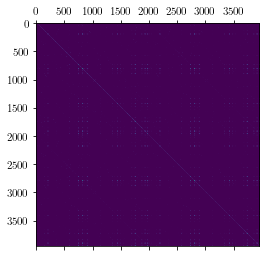

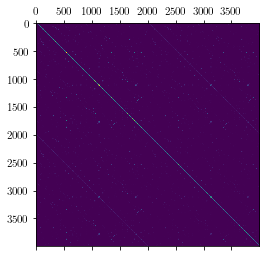

In [5]:
bott_index_strip = bott_index(lattice_strip, proj_strip)
bott_index_pbc = bott_index(lattice, proj_pbc)

In [6]:
chern_marker_strip = chern_marker(lattice_strip, proj_strip)
chern_marker_pbc = chern_marker(lattice, proj_pbc)
chern_marker_strip_fixed = chern_marker(lattice_strip, proj_strip, True)
chern_marker_pbc_fixed = chern_marker(lattice, proj_pbc, True)

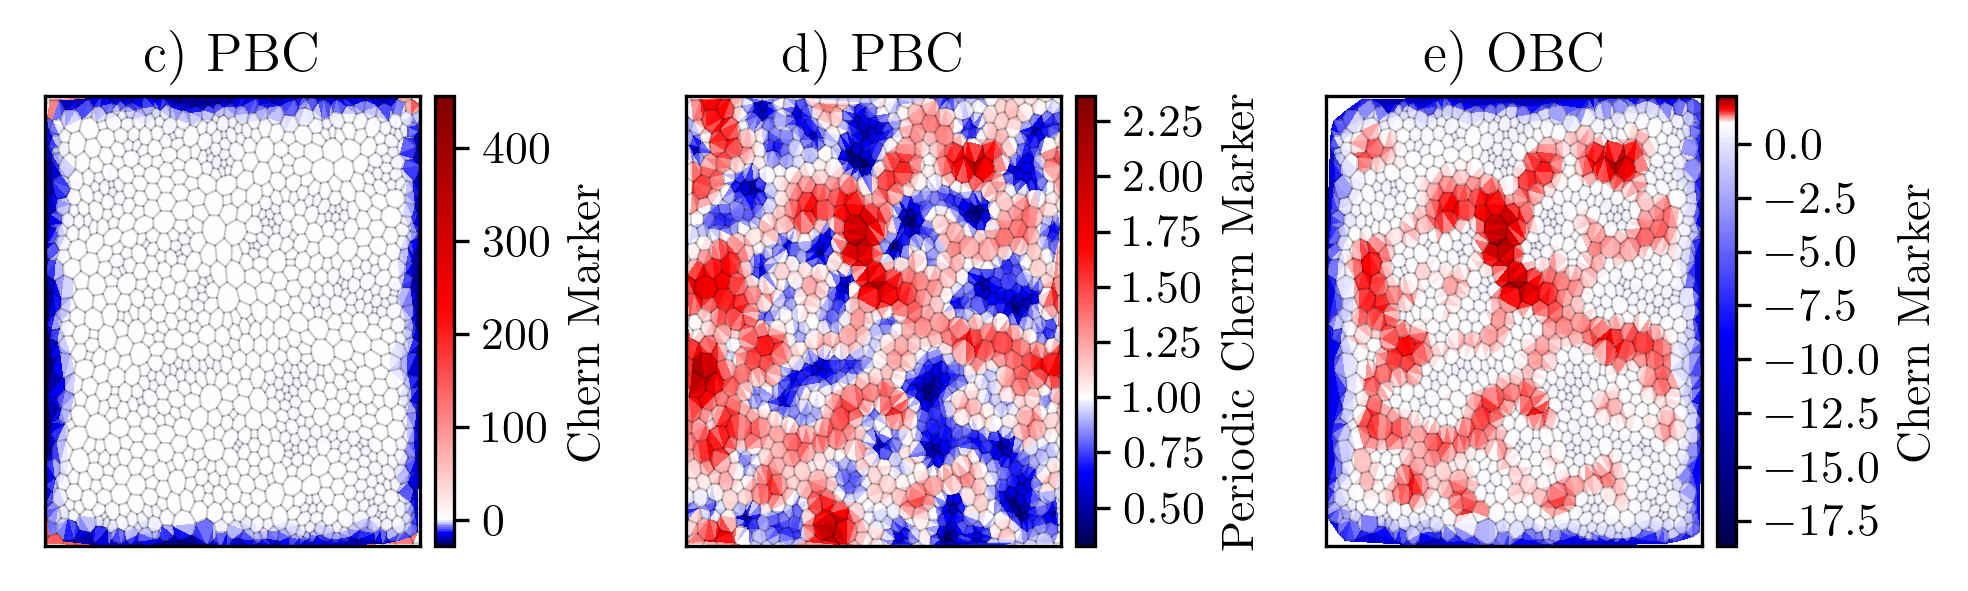

In [7]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1,3, figsize = (6.69291,2.1), dpi = 300, tight_layout=True)

titles = ['c) PBC', 'd) PBC', 'e) OBC']
labels = ['Chern Marker', 'Periodic Chern Marker', 'Chern Marker']


for n, l in enumerate([lattice, lattice, lattice_strip]):
    ax[n].set_xticks([])
    ax[n].set_yticks([])
    kplt.plot_edges(l, ax = ax[n], color = 'k', linewidth = 0.5, alpha = 0.2)

    x_vals = l.vertices.positions[:,0]
    y_vals = l.vertices.positions[:,1]

    z_vals = [chern_marker_pbc,chern_marker_pbc_fixed, chern_marker_strip][n]
    
    divnorm = colors.TwoSlopeNorm(vmin=z_vals.min(), vcenter=1, vmax=z_vals.max())
    pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, norm= divnorm, cmap= 'seismic', rasterized=True) 
    
    # z_vals = [chern_marker_pbc, chern_marker_strip][n]
    # pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, cmap= 'seismic', rasterized=True) 

    divider = make_axes_locatable(ax[n])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(pcm, cax=cax, orientation='vertical', label = labels[n])
    ax[n].set_title(titles[n])

plt.savefig('chern_markers.pdf', bbox_inches='tight')



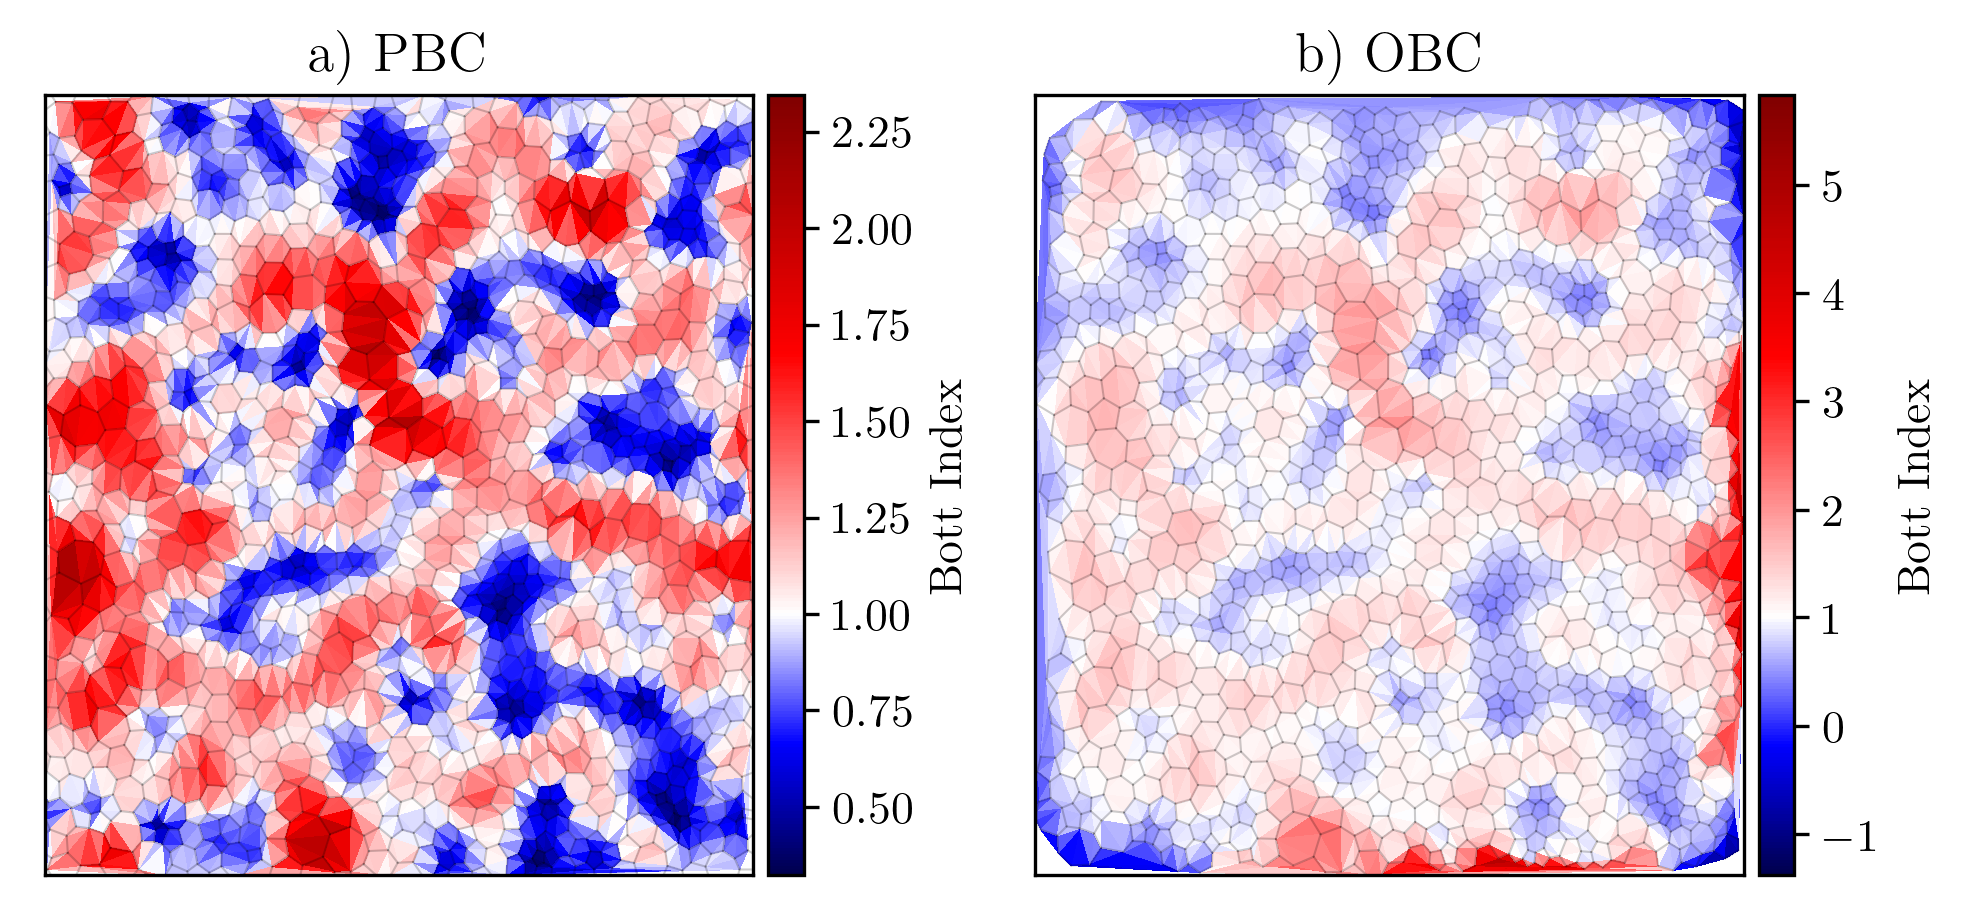

In [8]:
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1,2, figsize = (6.69291,3.2), dpi = 300, tight_layout=True)

titles = ['a) PBC', 'b) OBC']
labels = ['Bott Index', 'Bott Index']



for n, l in enumerate([lattice, lattice_strip]):
    ax[n].set_xticks([])
    ax[n].set_yticks([])
    kplt.plot_edges(l, ax = ax[n], color = 'k', linewidth = 0.5, alpha = 0.2)

    x_vals = l.vertices.positions[:,0]
    y_vals = l.vertices.positions[:,1]

    z_vals = [-bott_index_pbc, -bott_index_strip][n]
    
    divnorm = colors.TwoSlopeNorm(vmin=z_vals.min(), vcenter=1, vmax=z_vals.max())
    pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, norm= divnorm, cmap= 'seismic', rasterized=True) 
    # pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, cmap= 'seismic', rasterized=True) 
    
    # pcm = ax[n].tripcolor(x_vals, y_vals, z_vals, cmap= 'seismic', rasterized=True) 

    divider = make_axes_locatable(ax[n])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(pcm, cax=cax, orientation='vertical', label = labels[n])
    ax[n].set_title(titles[n])

plt.savefig('bott_indices.pdf', bbox_inches='tight')


In [9]:
print(np.average(chern_marker_pbc_fixed), 'cher pbc')
print(np.average(chern_marker_strip), 'cher strip')
print(np.average(chern_marker_pbc), 'cher pbc')

print(np.average(bott_index_strip), 'bott strip')
print(np.average(bott_index_pbc), 'bott pbc')


0.9999999999994884 cher pbc
-5.855331947871402e-15 cher strip
6.326672519207932e-14 cher pbc
-1.0000000000000329 bott strip
-0.9999999999999588 bott pbc
